In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
HISTORY_DIR = Path("../data/processed/historic")
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

def _load_eval_history(experiment_name: str) -> pd.DataFrame:
    df = pd.read_csv(HISTORY_DIR / f"{experiment_name}.csv")
    if "eval_loss" in df.columns:
        return df[df["eval_loss"].notna()].copy()
    return df.copy()

In [3]:
def plot_experiment(experiment_name: str):
    df_eval = _load_eval_history(experiment_name)

    plt.figure(figsize=(8, 4))
    plt.plot(df_eval["epoch"], df_eval["eval_f1_macro"], label="F1 Macro")
    plt.plot(df_eval["epoch"], df_eval["eval_precision_macro"], label="Precision Macro")
    plt.plot(df_eval["epoch"], df_eval["eval_recall_macro"], label="Recall Macro")

    plt.title(experiment_name)
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

def compare_experiments(experiments):
    plt.figure(figsize=(8, 4))
    for exp_name in experiments:
        df_eval = _load_eval_history(exp_name)
        plt.plot(df_eval["epoch"], df_eval["eval_f1_macro"], label=exp_name)

    plt.xlabel("Epoch")
    plt.ylabel("F1 Macro")
    plt.title("Comparação de Modelos")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

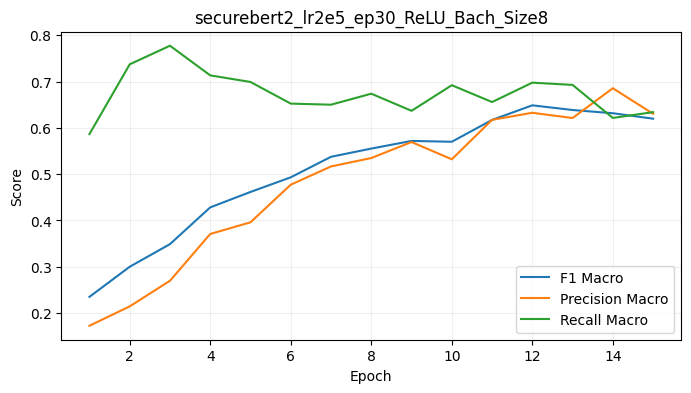

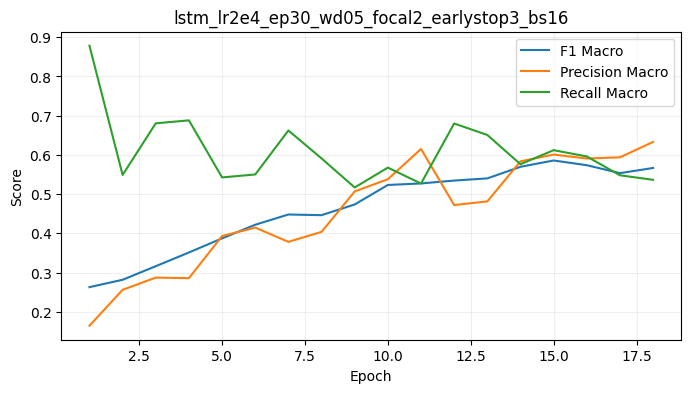

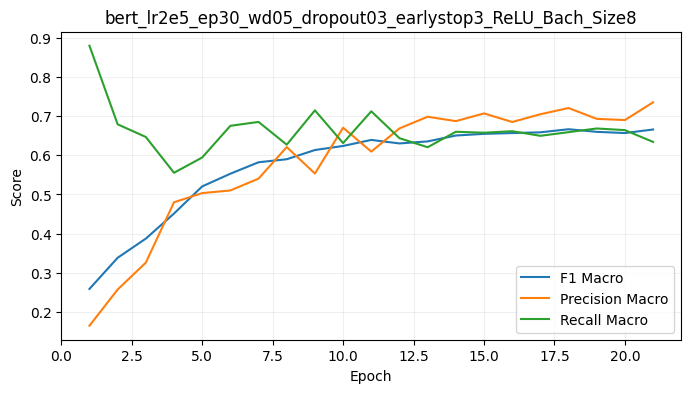

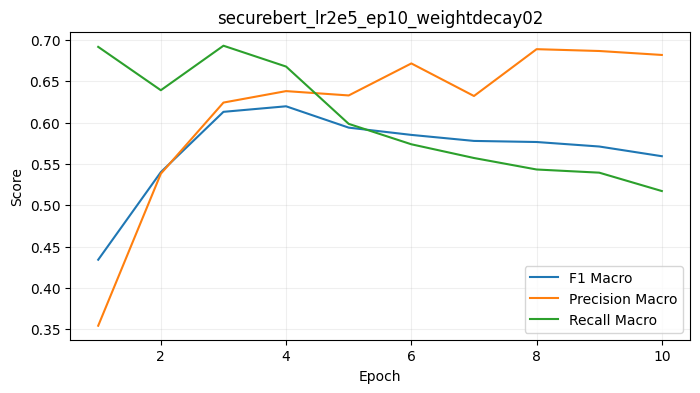

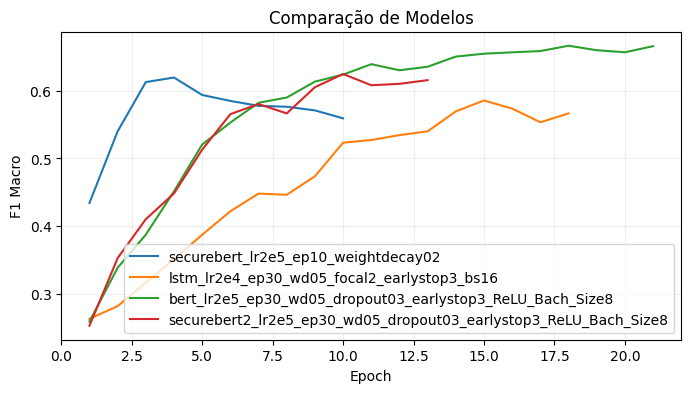

In [7]:
plot_experiment("securebert2_lr2e5_ep30_ReLU_Bach_Size8")
plot_experiment("lstm_lr2e4_ep30_wd05_focal2_earlystop3_bs16")
plot_experiment("bert_lr2e5_ep30_wd05_dropout03_earlystop3_ReLU_Bach_Size8")
plot_experiment("securebert_lr2e5_ep10_weightdecay02")
compare_experiments([
    "securebert_lr2e5_ep10_weightdecay02",
    "lstm_lr2e4_ep30_wd05_focal2_earlystop3_bs16",
    "bert_lr2e5_ep30_wd05_dropout03_earlystop3_ReLU_Bach_Size8",
    "securebert2_lr2e5_ep30_wd05_dropout03_earlystop3_ReLU_Bach_Size8"
])